In [1]:
from modules.strategies import Base_RSI
from backtesting_engine.backtest_engine import BacktestEngine
from modules.data import generate_historical_data
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import pandas as pd

import cProfile
import pstats
import random

In [2]:
strategy_configs = {
    'RSI': {
        'stream_key': 'alpaca',
        'tickers': ['AAPL','AMD','CSCO','GOOG','INTC','JNPR','META','MSFT','NFLX','NVDA','TSLA'],  # List of tickers to trade
        'period': 14,  # Historical data required per new price entry
        'overbought_th': {'entry': 55, 'exit':50},  # Overbought threshold for RSI
        'oversold_th': {'entry': 45, 'exit':50},  # Oversold threshold for RSI
        'plot':False,
    },
}

strategy_name = 'RSI'

In [3]:
days = 50
ticker_num = 5

def hist_to_pickle(days, ticker_num, strategy_configs):
    try:
        historical_data = pd.read_pickle(f'backtesting_engine/histdata_{days}D_{ticker_num}T_SHFL.pkl')
        print(f'Loaded df: {days}D/{ticker_num}T, {len(historical_data)} rows')
    except:
        print(f'New df: {days}D_{ticker_num}T, {len(historical_data)} rows')
        tickers =  strategy_configs[strategy_name]['tickers'][0:ticker_num]
        
        start_time = datetime.now() - timedelta(days=100)  
        end_time = datetime.now()
        
        historical_data = generate_historical_data(tickers, start_time, end_time)
        historical_data = historical_data.sample(frac=1)
        historical_data.to_pickle(f'backtesting_engine/histdata_{days}D_{ticker_num}T_SHFL.pkl')
    
    return historical_data
        
historical_data = hist_to_pickle(days, ticker_num, strategy_configs)
historical_data.head()

Loaded df: 50D/5T, 720005 rows


,timestamp,ticker,open,high,low,close
211073,2025-02-06 05:02:16.308478,AMD,2067.02,2070.03,2064.55,2069.40
528791,2025-02-26 20:18:16.308478,GOOG,1727.73,1729.56,1726.03,1727.77
316485,2025-01-10 09:53:16.308478,CSCO,1658.56,1666.57,1656.88,1662.24
235158,2025-02-22 22:27:16.308478,AMD,2306.24,2312.13,2301.56,2309.88
337281,2025-01-24 20:29:16.308478,CSCO,3079.99,3081.48,3077.52,3078.77


In [4]:
%%time
profiler = cProfile.Profile()
profiler.enable()
strategy = Base_RSI(strategy_configs[strategy_name], mode='backtest')
backtest = BacktestEngine(strategy, historical_data)
backtest.run_backtest()
profiler.disable()

stats = pstats.Stats(profiler)
stats.strip_dirs().sort_stats("cumulative").print_stats(20)  # Show top 20 slowest calls

Positions initialized: {'AAPL': None, 'AMD': None, 'CSCO': None, 'GOOG': None, 'INTC': None, 'JNPR': None, 'META': None, 'MSFT': None, 'NFLX': None, 'NVDA': None, 'TSLA': None}
         1927762 function calls (1927669 primitive calls) in 10.520 seconds

   Ordered by: cumulative time
   List reduced from 655 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    1.569    1.569    9.726    9.726 backtest_engine.py:48(run_backtest)
   106593    1.065    0.000    3.689    0.000 backtest_engine.py:105(get_portfolio_value)
   106593    0.426    0.000    2.570    0.000 fromnumeric.py:2177(sum)
   106593    1.013    0.000    2.050    0.000 fromnumeric.py:71(_wrapreduction)
        1    0.000    0.000    1.484    1.484 frame.py:12590(values)
        1    0.010    0.010    1.484    1.484 managers.py:1633(as_array)
        1    0.045    0.045    1.474    1.474 managers.py:1707(_interleave)
        5    0.000    0.000    1.360    0.272 

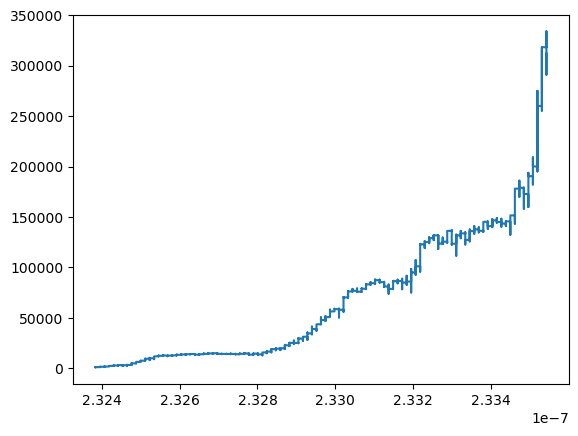

In [9]:
import matplotlib.dates as mdates
x,y = zip(*backtest.balance_hist)
x = mdates.date2num(x)
plt.plot(mdates.date2num(x),y)